In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/retail_sales_dataset.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(2030, 16)
OrderID                str
SalesRep               str
Region                 str
Country                str
City                   str
ProductCategory        str
ProductName            str
UnitPrice          float64
Quantity             int64
TotalSales         float64
Discount           float64
Profit             float64
OrderDate              str
Quarter                str
CustomerSegment        str
PaymentMethod          str
dtype: object
OrderID             0
SalesRep            0
Region              0
Country             0
City               19
ProductCategory     0
ProductName         0
UnitPrice           0
Quantity            0
TotalSales          0
Discount           16
Profit             17
OrderDate           0
Quarter             0
CustomerSegment    16
PaymentMethod      12
dtype: int64


In [18]:
# 1. Fix missing values
df['City'] = df['City'].fillna('Unknown')
df['CustomerSegment'] = df['CustomerSegment'].fillna(df['CustomerSegment'].mode()[0])
df['PaymentMethod'] = df['PaymentMethod'].fillna(df['PaymentMethod'].mode()[0])
df['Discount'] = df['Discount'].fillna(df['Discount'].median())
df['Profit'] = df['Profit'].fillna(df['Profit'].median())

# 2. Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# 3. Remove duplicates
df = df.drop_duplicates()

# 4. Add Month column
df['Month'] = df['OrderDate'].dt.to_period('M')

print(df.isnull().sum())
print(df.shape)

OrderID            0
SalesRep           0
Region             0
Country            0
City               0
ProductCategory    0
ProductName        0
UnitPrice          0
Quantity           0
TotalSales         0
Discount           0
Profit             0
OrderDate          0
Quarter            0
CustomerSegment    0
PaymentMethod      0
Month              0
dtype: int64
(2005, 17)


In [19]:
# Q1 - Total Sales by Region
region_sales = df.groupby('Region')['TotalSales'].sum().sort_values(ascending=False)
print(region_sales)

Region
North America           2.250019e+06
Europe                  1.716204e+06
Asia Pacific            1.211534e+06
Latin America           5.032720e+05
Middle East & Africa    2.321168e+05
Name: TotalSales, dtype: float64


In [20]:
# Q2 - Top 5 Sales Reps
top_sales_reps = df.groupby('SalesRep')['TotalSales'].sum().sort_values(ascending=False).head(5)
print(top_sales_reps)

SalesRep
Fatima Al-Hassan    806895.719640
Amara Diallo        446394.254763
Carlos Mendes       442227.290000
David Kim           431102.950000
Isabella Rossi      431006.601190
Name: TotalSales, dtype: float64


In [21]:
# Q3 - Profit by Product Category
category_profit = df.groupby('ProductCategory')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

ProductCategory
Software              1.481989e+06
Office Supplies       2.662359e+05
Electronics           2.258012e+05
Clothing & Apparel    2.009472e+05
Home & Kitchen        1.933986e+05
Name: Profit, dtype: float64


In [22]:
# Q4 - Monthly Revenue Trend
monthly_revenue = df.groupby('Month')['TotalSales'].sum().sort_index()
print(monthly_revenue)

Month
2022-01    111117.324763
2022-02    386962.878448
2022-03    117975.680000
2022-04    148346.140000
2022-05     86382.940000
2022-06     42287.340000
2022-07    136781.000000
2022-08    201883.561190
2022-09    238519.800000
2022-10    388428.980000
2022-11    177990.110000
2022-12    269569.640000
2023-01    342779.130000
2023-02     93527.281414
2023-03     70959.670000
2023-04     77968.660000
2023-05    144959.403262
2023-06     70866.360000
2023-07     67466.020000
2023-08     83094.042998
2023-09     83719.310000
2023-10    243513.501844
2023-11    230102.354657
2023-12    181317.590000
2024-01    175123.140000
2024-02     58542.640000
2024-03     52877.670000
2024-04    202735.362321
2024-05    184596.270000
2024-06    123124.000000
2024-07    262227.180000
2024-08     89765.030000
2024-09    182187.270000
2024-10    144149.950000
2024-11    269170.200000
2024-12    172127.820000
Freq: M, Name: TotalSales, dtype: float64


In [23]:
# Q5 - Sales by Customer Segment
segment_sales = df.groupby('CustomerSegment')['TotalSales'].sum().sort_values(ascending=False)
print(segment_sales)

CustomerSegment
SMB                2.635256e+06
Enterprise         1.591969e+06
Retail Consumer    8.651001e+05
Government         4.245783e+05
Non-Profit         3.962417e+05
Name: TotalSales, dtype: float64


## Business Analysis Findings

**1. Regional Performance:** North America leads with £2.25M in 
total sales — more than double Latin America (£503K). 
The business should investigate why Middle East & Africa 
is significantly underperforming at only £232K.

**2. Top Sales Rep:** Fatima Al-Hassan generates the highest 
individual revenue. Understanding her approach could help 
train underperforming reps.

**3. Product Profitability:** Software has the highest profit 
margin at 58.47% despite not being the highest volume category. 
The business should prioritize Software sales over lower margin 
categories like Electronics.

**4. Seasonality:** October 2022 recorded peak sales. 
The business should prepare inventory and staffing 
before Q4 each year.

**5. Customer Segments:** SMB generates the most sales volume. 
Enterprise customers likely have higher individual order values 
but fewer orders — worth investigating further.

C:\Users\HP\AppData\Local\Temp\ipykernel_8204\1887254425.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.values, y=region_sales.index, palette='Blues_r')


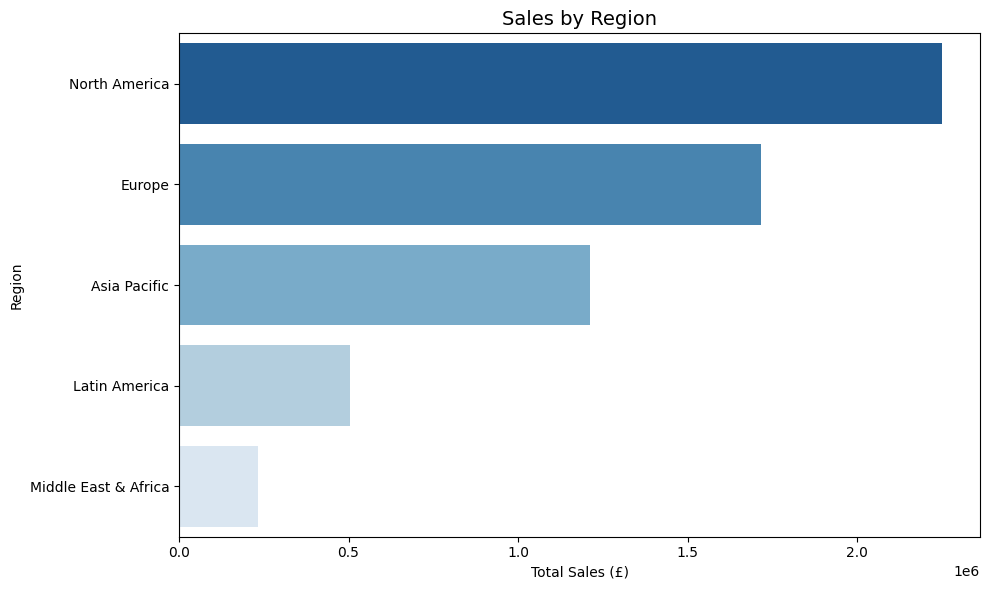

C:\Users\HP\AppData\Local\Temp\ipykernel_8204\1887254425.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.values, y=category_profit.index, palette='Greens_r')


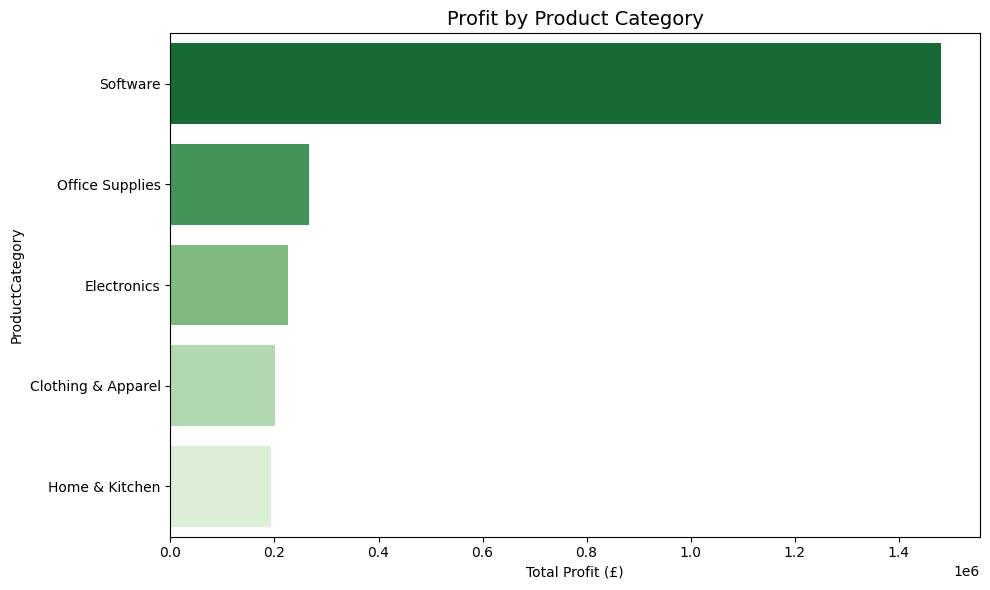

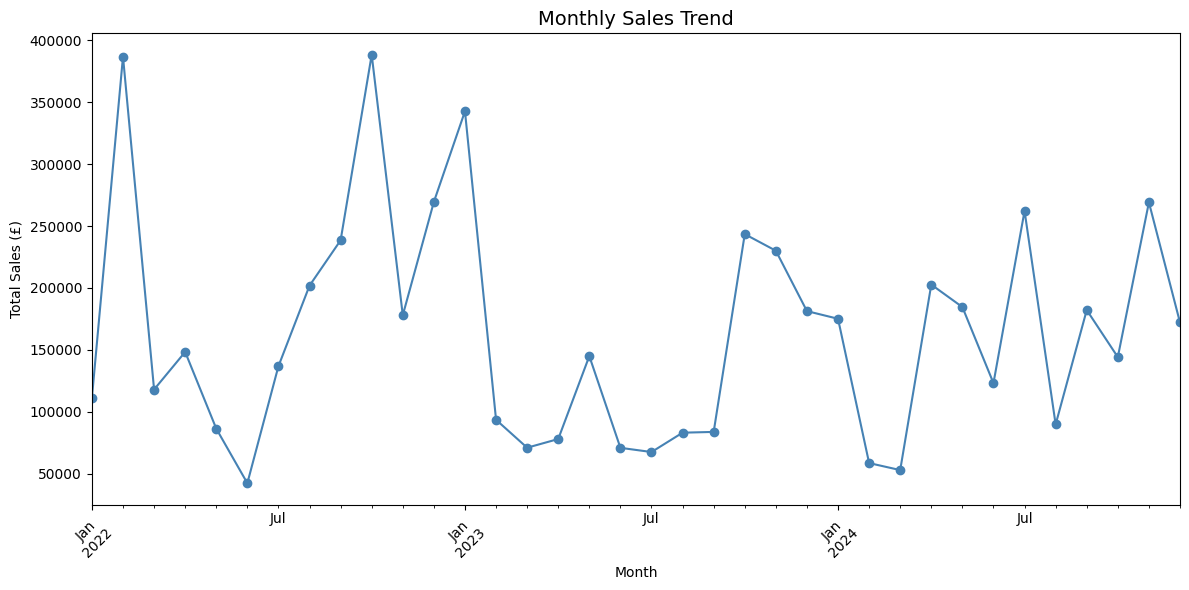

C:\Users\HP\AppData\Local\Temp\ipykernel_8204\1887254425.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales.values, y=segment_sales.index, palette='Oranges_r')


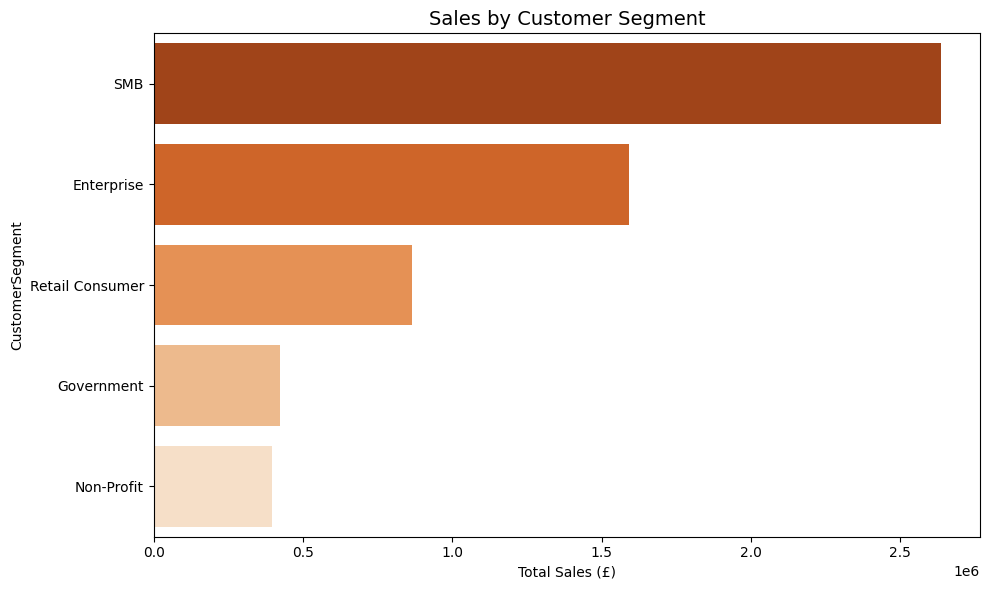

In [24]:
# Sales by Region
plt.figure(figsize=(10,6))
sns.barplot(x=region_sales.values, y=region_sales.index, palette='Blues_r')
plt.title('Sales by Region', fontsize=14)
plt.xlabel('Total Sales (£)')
plt.tight_layout()

plt.show()

# Profit by Product Category 
plt.figure(figsize=(10,6))
sns.barplot(x=category_profit.values, y=category_profit.index, palette='Greens_r')
plt.title('Profit by Product Category', fontsize=14)
plt.xlabel('Total Profit (£)')
plt.tight_layout()
plt.show()

# Monthly Sales Trend
monthly_revenue = df.groupby('Month')['TotalSales'].sum().sort_index()

plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/monthly_sales_trend.png')
plt.show()

# Sales by Customer Segment
plt.figure(figsize=(10,6))  
sns.barplot(x=segment_sales.values, y=segment_sales.index, palette='Oranges_r')
plt.title('Sales by Customer Segment', fontsize=14)
plt.xlabel('Total Sales (£)')
plt.tight_layout()
plt.show()

In [ ]:
# Export for Power BI
region_sales.reset_index().to_csv('../data/exports/region_sales.csv', index=False)
category_profit.reset_index().to_csv('../data/exports/category_profit.csv', index=False)
monthly_revenue.reset_index().to_csv('../data/exports/monthly_revenue.csv', index=False)
segment_sales.reset_index().to_csv('../data/exports/segment_sales.csv', index=False)

# Export clean dataset
df.to_csv('../data/exports/financial_sales_clean.csv', index=False)

# Save charts for visuals
plt.savefig('../visuals/region_sales.png')
plt.savefig('../visuals/category_profit.png')
plt.savefig('../visuals/monthly_sales_trend.png')
plt.savefig('../visuals/segment_sales.png')

<Figure size 640x480 with 0 Axes>